# Get Data

In [2]:
import pandas as pd

merged_enrpn = pd.read_csv("./csv/merged_enron.csv")
merged_enron_preprocessed = pd.read_csv("./csv/preprocessed_merged_enron_data.csv")

In [33]:
merged_enrpn["len"] = merged_enrpn.apply(lambda x: len(f"{x['Subject']} {x['Body']}".split()), axis=1)
merged_enron_preprocessed["len"] = merged_enron_preprocessed.apply(
    lambda x: len(x["Text"].split()), axis=1
)

In [3]:
import ast

merged_enron_preprocessed_X, merged_enron_preprocessed_y = merged_enron_preprocessed["Text"], merged_enron_preprocessed["Label"]

merged_enron_preprocessed_X = merged_enron_preprocessed_X.apply(lambda x: ast.literal_eval(x))

In [ ]:
import joblib

def save_preprocessed_data(preprocessed_X, preprocessed_y, X_name="X name"):
    joblib.dump({
        "features": preprocessed_X,
        "labels": preprocessed_y
    }, f"./preprocess/{X_name}.pkl")

# Import preprocessing.py

In [ ]:
import sys

sys.path.append("../Handlers/")

# Lemmatizing

In [ ]:
import preprocessing

merged_enron_lemmatized_X = merged_enron_preprocessed_X.apply(preprocessing.lemmatizing)

print(merged_enron_lemmatized_X)

[nltk_data] Downloading package punkt to E:/nltk...
[nltk_data]   Package punkt is already up-to-date!


0                          christmas tree farm picture nan
1        vastar resource inc gary production high islan...
2        calpine daily gas nomination calpine daily gas...
3        issue fyi see note already done stella forward...
4        meter DATE allocation fyi forwarded lauri alle...
                               ...                        
33710    iso q good news c edaliss val edumm vl eoggra ...
33711    prescript medicine special precise put buck ba...
33712    next generation online pharmacy ready rock let...
33713    bloow time time learn last time longer bed rea...
33714    dear sir interested hi need software give link...
Name: Text, Length: 33715, dtype: object


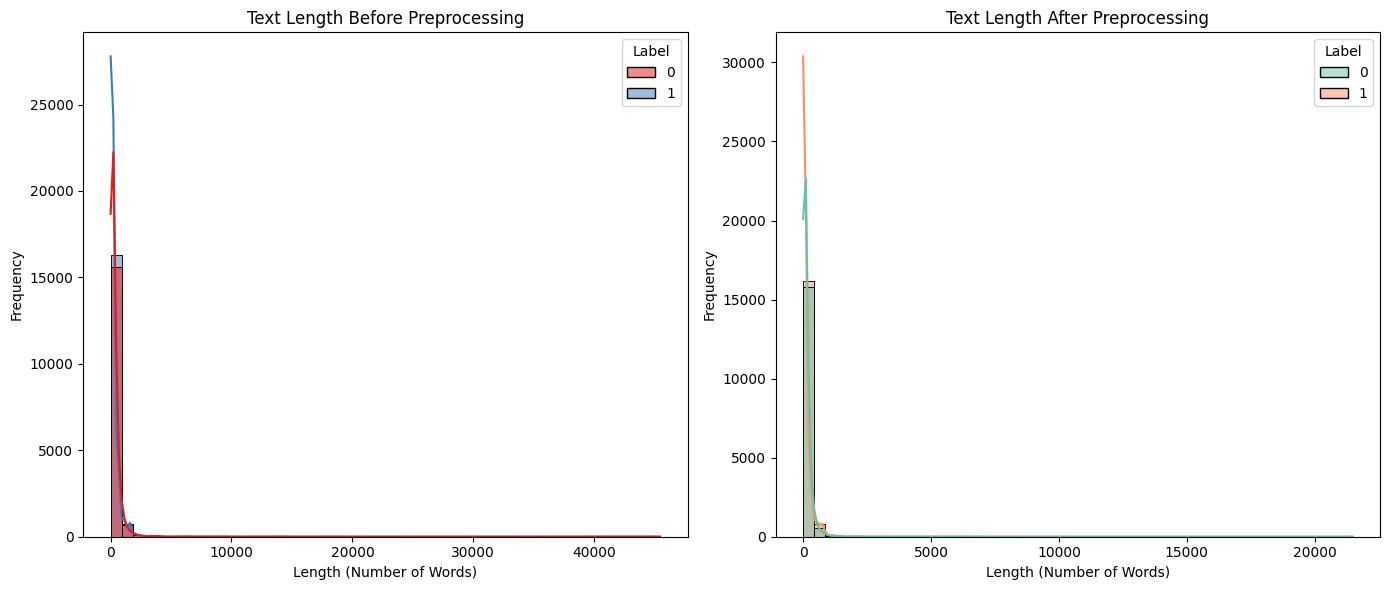

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Original text length
plt.subplot(1, 2, 1)
sns.histplot(data=merged_enrpn, x='len', hue='Label', bins=50, kde=True, palette='Set1')
plt.title('Text Length Before Preprocessing')
plt.xlabel('Length (Number of Words)')
plt.ylabel('Frequency')

# Processed text length
plt.subplot(1, 2, 2)
sns.histplot(data=merged_enron_preprocessed, x='len', hue='Label', bins=50, kde=True, palette='Set2')
plt.title('Text Length After Preprocessing')
plt.xlabel('Length (Number of Words)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

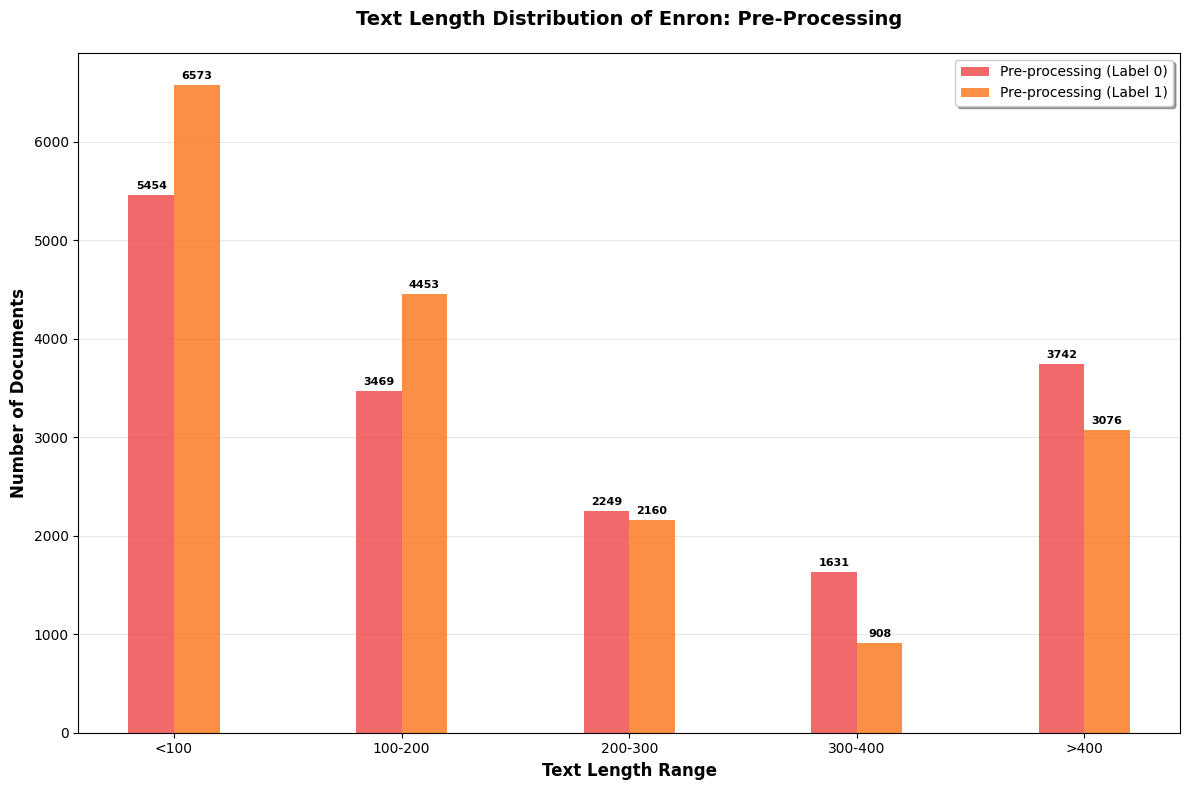

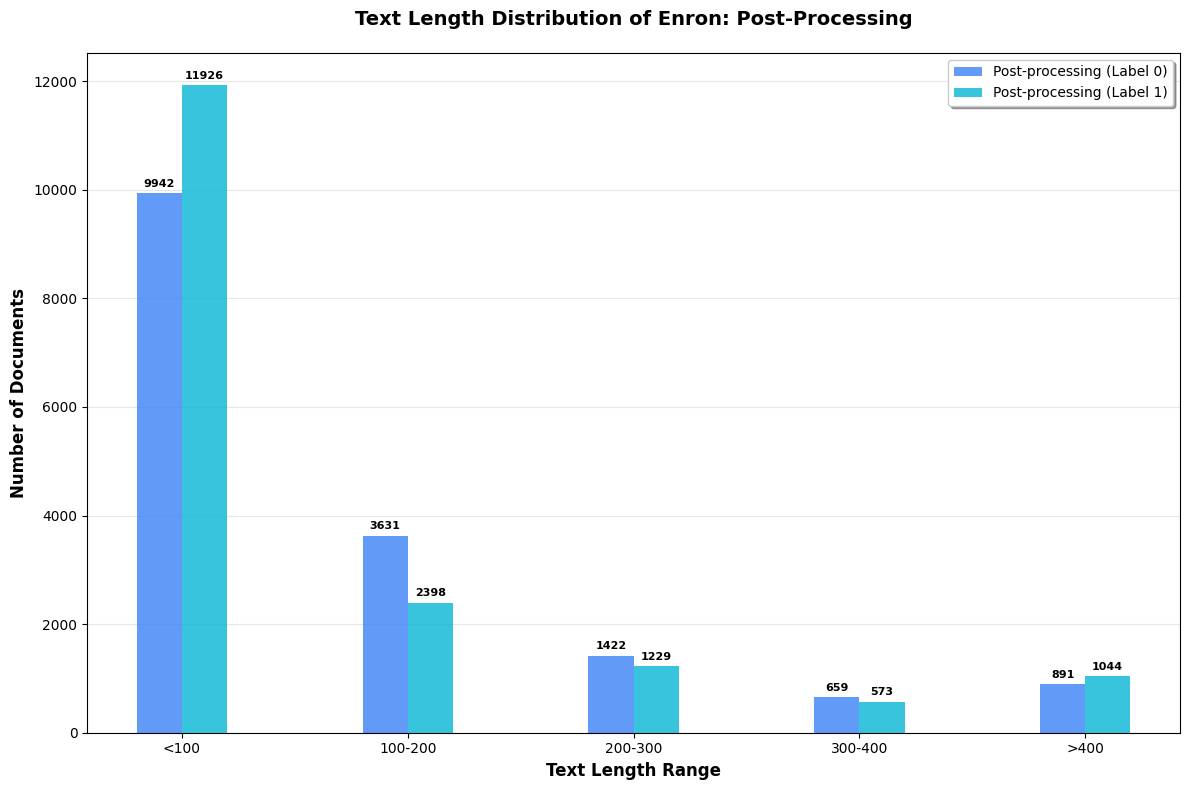


TEXT LENGTH DISTRIBUTION SUMMARY
Range        Pre-0    Pre-1    Post-0   Post-1  
------------------------------------------------------------
<100         5454     6573     9942     11926   
100-200      3469     4453     3631     2398    
200-300      2249     2160     1422     1229    
300-400      1631     908      659      573     
>400         3742     3076     891      1044    
------------------------------------------------------------
Total        16545    17170    16545    17170   

Total documents: 33715

Visualization complete!


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def categorize_length(length):
    """Categorize text length into predefined ranges."""
    if length < 100:
        return '<100'
    elif length < 200:
        return '100-200'
    elif length < 300:
        return '200-300'
    elif length < 400:
        return '300-400'
    else:
        return '>400'

def process_text_data(texts, labels, stage_name):
    """Process text data and return counts by length range and label."""
    ranges = ['<100', '100-200', '200-300', '300-400', '>400']
    
    # Initialize counts dictionary
    counts = {
        0: {range_key: 0 for range_key in ranges},
        1: {range_key: 0 for range_key in ranges}
    }
    
    # Count documents in each category
    for text, label in zip(texts, labels):
        if not isinstance(text, (str, list)):
            length = 0
        else:
            if isinstance(text, str):
                length = len(text.split())
            else:
                length = len(text)
        range_key = categorize_length(length)
        counts[label][range_key] += 1
    
    return counts

def create_pre_text_length_comparison_plot(pre_texts, labels, 
                                     title="Text Length Distribution Comparison",
                                     figsize=(12, 8)):
    """
    Create a grouped bar plot comparing text length distributions.
    
    Parameters:
    - pre_texts: list of original texts before preprocessing
    - post_texts: list of texts after preprocessing (lemmatizing/stemming)
    - labels: list of binary labels (0 or 1)
    - title: plot title
    - figsize: figure size tuple
    """
    
    # Process data for both stages
    pre_counts = process_text_data(pre_texts, labels, "Pre-processing")
    # post_counts = process_text_data(post_texts, labels, "Post-processing")
    
    # Set up the plot
    ranges = ['<100', '100-200', '200-300', '300-400', '>400']
    x = np.arange(len(ranges))
    width = 0.2  # Width of bars
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bars for each category
    bars1 = ax.bar(x - 0.5*width, [pre_counts[0][r] for r in ranges], 
                   width, label='Pre-processing (Label 0)', 
                   color='#ef4444', alpha=0.8)
    
    bars2 = ax.bar(x + 0.5*width, [pre_counts[1][r] for r in ranges], 
                   width, label='Pre-processing (Label 1)', 
                   color='#f97316', alpha=0.8)
    # bars1 = ax.bar(x - 1.5*width, [pre_counts[0][r] for r in ranges], 
    #                width, label='Pre-processing (Label 0)', 
    #                color='#ef4444', alpha=0.8)
    
    # bars2 = ax.bar(x - 0.5*width, [pre_counts[1][r] for r in ranges], 
    #                width, label='Pre-processing (Label 1)', 
    #                color='#f97316', alpha=0.8)
    
    # bars3 = ax.bar(x + 0.5*width, [post_counts[0][r] for r in ranges], 
    #                width, label='Post-processing (Label 0)', 
    #                color='#3b82f6', alpha=0.8)
    
    # bars4 = ax.bar(x + 1.5*width, [post_counts[1][r] for r in ranges], 
    #                width, label='Post-processing (Label 1)', 
    #                color='#06b6d4', alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Text Length Range', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Documents', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(ranges)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Add value labels on top of bars
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only add label if height > 0
                ax.annotate(f'{int(height)}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom',
                           fontsize=8, fontweight='bold')
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    # add_value_labels(bars3)
    # add_value_labels(bars4)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig, ax, pre_counts

def create_post_text_length_comparison_plot(post_texts, labels, 
                                     title="Text Length Distribution Comparison",
                                     figsize=(12, 8)):
    """
    Create a grouped bar plot comparing text length distributions.
    
    Parameters:
    - pre_texts: list of original texts before preprocessing
    - post_texts: list of texts after preprocessing (lemmatizing/stemming)
    - labels: list of binary labels (0 or 1)
    - title: plot title
    - figsize: figure size tuple
    """
    
    # Process data for both stages
    # pre_counts = process_text_data(pre_texts, labels, "Pre-processing")
    post_counts = process_text_data(post_texts, labels, "Post-processing")
    
    # Set up the plot
    ranges = ['<100', '100-200', '200-300', '300-400', '>400']
    x = np.arange(len(ranges))
    width = 0.2  # Width of bars
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bars for each category
    # bars1 = ax.bar(x - 1.5*width, [pre_counts[0][r] for r in ranges], 
    #                width, label='Pre-processing (Label 0)', 
    #                color='#ef4444', alpha=0.8)
    
    # bars2 = ax.bar(x - 0.5*width, [pre_counts[1][r] for r in ranges], 
    #                width, label='Pre-processing (Label 1)', 
    #                color='#f97316', alpha=0.8)
    
    bars3 = ax.bar(x - 0.5*width, [post_counts[0][r] for r in ranges], 
                   width, label='Post-processing (Label 0)', 
                   color='#3b82f6', alpha=0.8)
    
    bars4 = ax.bar(x + 0.5*width, [post_counts[1][r] for r in ranges], 
                   width, label='Post-processing (Label 1)', 
                   color='#06b6d4', alpha=0.8)
    
    # Customize the plot
    ax.set_xlabel('Text Length Range', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Documents', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(ranges)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Add value labels on top of bars
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:  # Only add label if height > 0
                ax.annotate(f'{int(height)}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),  # 3 points vertical offset
                           textcoords="offset points",
                           ha='center', va='bottom',
                           fontsize=8, fontweight='bold')
    
    # add_value_labels(bars1)
    # add_value_labels(bars2)
    add_value_labels(bars3)
    add_value_labels(bars4)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig, ax, post_counts


def print_summary_statistics(pre_counts, post_counts):
    """Print summary statistics of the text length distribution."""
    ranges = ['<100', '100-200', '200-300', '300-400', '>400']
    
    print("\n" + "="*60)
    print("TEXT LENGTH DISTRIBUTION SUMMARY")
    print("="*60)
    
    print(f"{'Range':<12} {'Pre-0':<8} {'Pre-1':<8} {'Post-0':<8} {'Post-1':<8}")
    print("-" * 60)
    
    for range_key in ranges:
        print(f"{range_key:<12} {pre_counts[0][range_key]:<8} "
              f"{pre_counts[1][range_key]:<8} {post_counts[0][range_key]:<8} "
              f"{post_counts[1][range_key]:<8}")
    
    # Calculate totals
    pre_total_0 = sum(pre_counts[0].values())
    pre_total_1 = sum(pre_counts[1].values())
    post_total_0 = sum(post_counts[0].values())
    post_total_1 = sum(post_counts[1].values())
    
    print("-" * 60)
    print(f"{'Total':<12} {pre_total_0:<8} {pre_total_1:<8} "
          f"{post_total_0:<8} {post_total_1:<8}")
    
    print(f"\nTotal documents: {pre_total_0 + pre_total_1}")

# Main execution
if __name__ == "__main__":
    # Option 2: Load from CSV (uncomment to use)
    # pre_texts, post_texts, labels = load_data_from_csv('your_data.csv')
    pre_texts, labels = merged_enrpn["Subject"] + " " + merged_enrpn["Body"], merged_enrpn["Label"]
    post_texts = merged_enron_preprocessed_X
    
    # Create the visualization
    fig, ax, pre_counts = create_pre_text_length_comparison_plot(
        pre_texts, labels,
        title="Text Length Distribution of Enron: Pre-Processing"
    )

    plt.show()

    fig, ax, post_counts = create_post_text_length_comparison_plot(
        post_texts, labels,
        title="Text Length Distribution of Enron: Post-Processing"
    )

    plt.show()
    
    # Print summary statistics
    print_summary_statistics(pre_counts, post_counts)
    
    
    
    # Optional: Save the plot
    # plt.savefig('text_length_comparison.png', dpi=300, bbox_inches='tight')
    
    print("\nVisualization complete!")

# Lemmatizing + CountVectorizer

In [ ]:
# merged_enron_lemmatized_countvec_X = preprocessing.vectorizing(merged_enron_lemmatized_X, "countvectorizer", min_df=5)

# print("CountVectorizer shape for Merged Enron:", merged_enron_lemmatized_countvec_X.shape)

In [ ]:
# save_preprocessed_data(merged_enron_lemmatized_countvec_X, merged_enron_preprocessed_y, "enron_lemmatized_countvec")

# Lemmatizing + TF-IDF Vectoizer

In [ ]:
# merged_enron_lemmatized_tfidf_X = preprocessing.vectorizing(merged_enron_lemmatized_X, "tfidf", min_df=6)

# print("TF-IDF shape for Merged Enron:", merged_enron_lemmatized_tfidf_X.shape)

In [ ]:
# save_preprocessed_data(merged_enron_lemmatized_tfidf_X, merged_enron_preprocessed_y, "enron_lemmatized_tfidf")

# Stemming

In [ ]:
# merged_enron_stemming_X = merged_enron_preprocessed_X.apply(preprocessing.stemming)

# Stemming + CountVectorizer

In [ ]:
# merged_enron_stemming_countvec_X = preprocessing.vectorizing(merged_enron_stemming_X, "countvectorizer", min_df=5)

In [ ]:
# save_preprocessed_data(merged_enron_stemming_countvec_X, merged_enron_preprocessed_y, "enron_stemmed_countvec")

# Stemming + TfidfVectorizer

In [ ]:
# merged_enron_stemming_tfidf_X = preprocessing.vectorizing(merged_enron_stemming_X, "tfidf", min_df=6)

# print("TF-IDF shape for Merged Enron:", merged_enron_stemming_tfidf_X.shape)

In [ ]:
# save_preprocessed_data(merged_enron_stemming_tfidf_X, merged_enron_preprocessed_y, "enron_stemmed_tfidf")